# Baseline: Classification via Promting

## Create a dataset

In [1]:
from utils.data_load import load_data

train, test = load_data()

Train: 800, Test: 160


## Explorative Dataanalysis
- looking for the class distribution -> no class imbalance

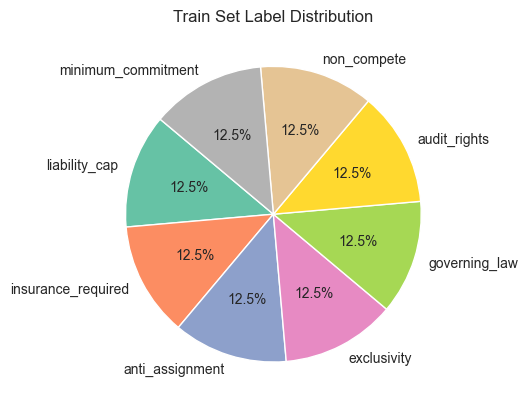

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_palette("Set2")

train_df = pd.DataFrame(train)
plt.pie(train_df["label"].value_counts(), labels=train_df["label"].value_counts().index, autopct="%1.1f%%", startangle=140)
plt.title("Train Set Label Distribution")
plt.show()

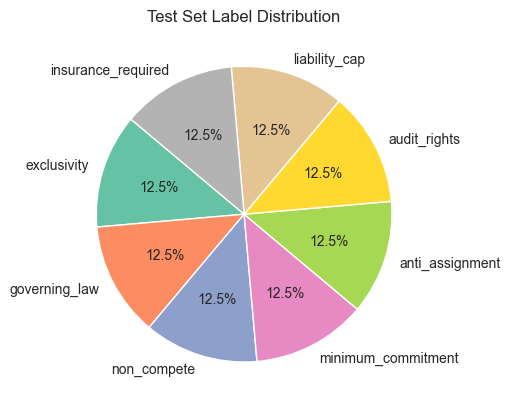

In [3]:
test_df = pd.DataFrame(test)
plt.pie(test_df["label"].value_counts(), labels=test_df["label"].value_counts().index, autopct="%1.1f%%", startangle=140)
plt.title("Test Set Label Distribution")
plt.show()

## Baseline: Classification via Promting
- selected model qwen3.5-0.8b

### Zero-shot vs few-shot promting

In [4]:
CATEGORIES = list(train_df["label"].unique())

In [5]:
MODEL = "qwen3.5:0.8b"
ZERO_SHOT_PROMT = f""" Classify the following legal clause into one of the following categories: {CATEGORIES}. Output the SINGLE label that best matches the clause below. 
                       CLAUSE: """

In [6]:
few_shot_examples = []
for label in CATEGORIES:
    class_examples = [item for item in train if item["label"] == label][:5] 
    for example in class_examples:
        few_shot_examples.append(f"EXAMPLE: {example['text']} LABEL: {example['label']}")

FEW_SHOT_PROMT = f""" Classify the following legal clause into one of the following categories:  {CATEGORIES}.
                      Here are some examples of clauses and their corresponding labels to help you understand the categories:{few_shot_examples}. 
                      Output the SINGLE label that best matches the clause below.
                      CLAUSE: """

In [7]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen3.5-0.8B")

len(tokenizer.encode(FEW_SHOT_PROMT)) #check token length of one example to estimate how many examples we can fit in the context window of the model

3221

### Generating predictions

In [8]:
import tqdm as tqdm
from ollama import chat

def classify_clause(model, clause, promt):
    response = chat(model=MODEL,
                    messages=[{"role": "system", "content": "You are a legal assistant that classifies legal clauses into specific categories. Always output ONLY ONE category label without any explanation."},
                              {"role": "user", "content": f"{promt} {clause}"}],
                    think=False, #reducing response time by skipping the "thinking" phase of the model from ~2 hours to ~2 minutes
                    options={"temperature": 0.0}) #ensure deterministic output, no creativity needed for classification task
    return response.message.content.strip()

def predict(model, clauses, promt):
    prediction_df = []
    for clause in tqdm.tqdm(clauses):
        pred = classify_clause(model, clause, promt)
        prediction_df.append({"text": clause, "label": pred})
    return prediction_df

In [9]:
zero_shot_predictions = predict(MODEL, test_df["text"], ZERO_SHOT_PROMT)

100%|██████████| 160/160 [02:05<00:00,  1.27it/s]


In [10]:
few_shot_predictions = predict(MODEL, test_df["text"], FEW_SHOT_PROMT)

100%|██████████| 160/160 [02:58<00:00,  1.12s/it]


#### Validate the predictions

In [11]:
zs_df = pd.DataFrame(zero_shot_predictions)
zs_df["label"].value_counts()

label
exclusivity           73
liability_cap         40
governing_law         20
audit_rights          16
non_compete            4
minimum_commitment     3
anti_assignment        2
insurance_required     2
Name: count, dtype: int64

In [12]:
fs_df = pd.DataFrame(few_shot_predictions)
fs_df["label"].value_counts()

label
non_compete           38
exclusivity           20
governing_law         20
audit_rights          19
minimum_commitment    18
anti_assignment       18
insurance_required    15
liability_cap         12
Name: count, dtype: int64

# Evaluation

Classification Report:
                    precision    recall  f1-score   support

   anti_assignment       1.00      0.10      0.18        20
      audit_rights       1.00      0.80      0.89        20
       exclusivity       0.27      1.00      0.43        20
     governing_law       0.95      0.95      0.95        20
insurance_required       1.00      0.10      0.18        20
     liability_cap       0.28      0.55      0.37        20
minimum_commitment       1.00      0.15      0.26        20
       non_compete       0.25      0.05      0.08        20

          accuracy                           0.46       160
         macro avg       0.72      0.46      0.42       160
      weighted avg       0.72      0.46      0.42       160

Confusion Matrix:


(0.4625, 0.4179377930780455)

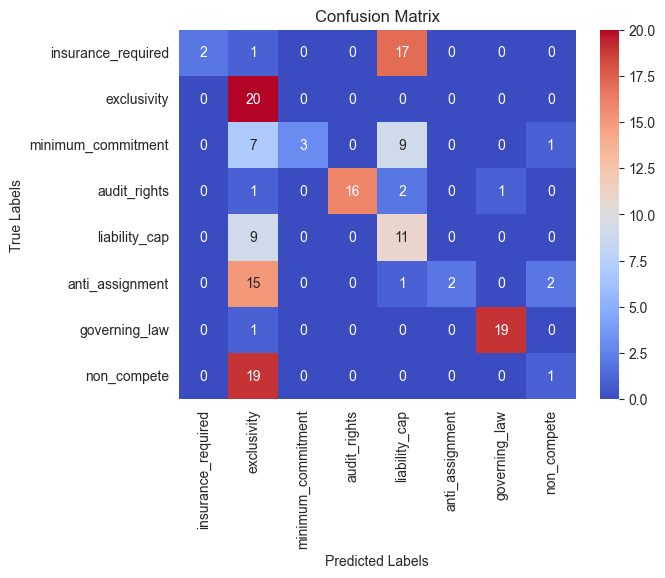

In [13]:
from utils.evaluate_pred import evaluate_pred

evaluate_pred(test_df, zero_shot_predictions)

Classification Report:
                    precision    recall  f1-score   support

   anti_assignment       1.00      0.90      0.95        20
      audit_rights       1.00      0.95      0.97        20
       exclusivity       0.85      0.85      0.85        20
     governing_law       1.00      1.00      1.00        20
insurance_required       1.00      0.75      0.86        20
     liability_cap       0.83      0.50      0.62        20
minimum_commitment       0.89      0.80      0.84        20
       non_compete       0.47      0.90      0.62        20

          accuracy                           0.83       160
         macro avg       0.88      0.83      0.84       160
      weighted avg       0.88      0.83      0.84       160

Confusion Matrix:


(0.83125, 0.8395831463605965)

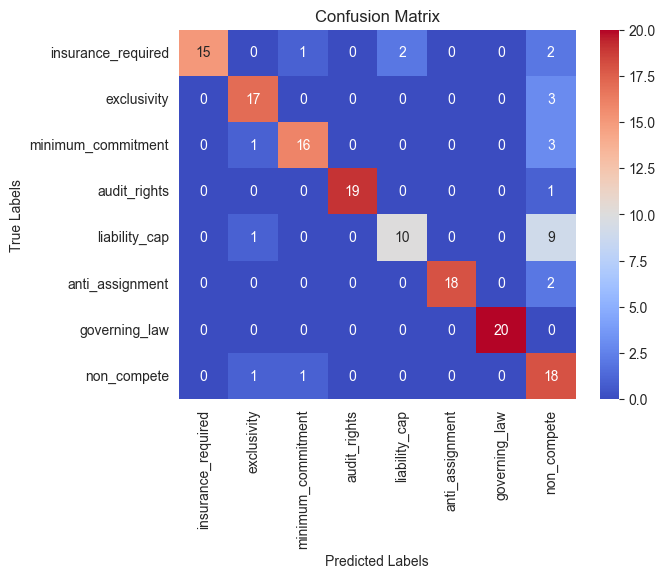

In [14]:
evaluate_pred(test_df, few_shot_predictions)